## 1. Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

df = pd.read_csv("spambase_csv.csv")
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
df.shape


(4601, 58)

In [ ]:
df.isnull().sum().sum()


np.int64(0)

In [ ]:
df['class'].value_counts()


class
0    2788
1    1813
Name: count, dtype: int64

## 2. Exploratory Data Analysis

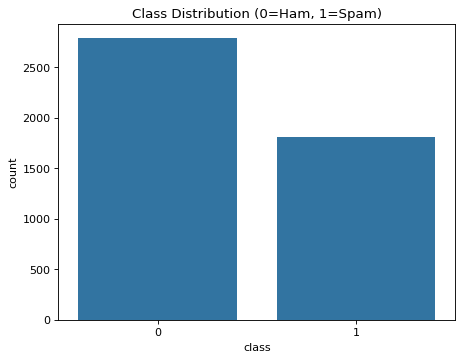

In [ ]:
sns.countplot(x='class', data=df)
plt.title("Class Distribution (0=Ham, 1=Spam)")
plt.show()


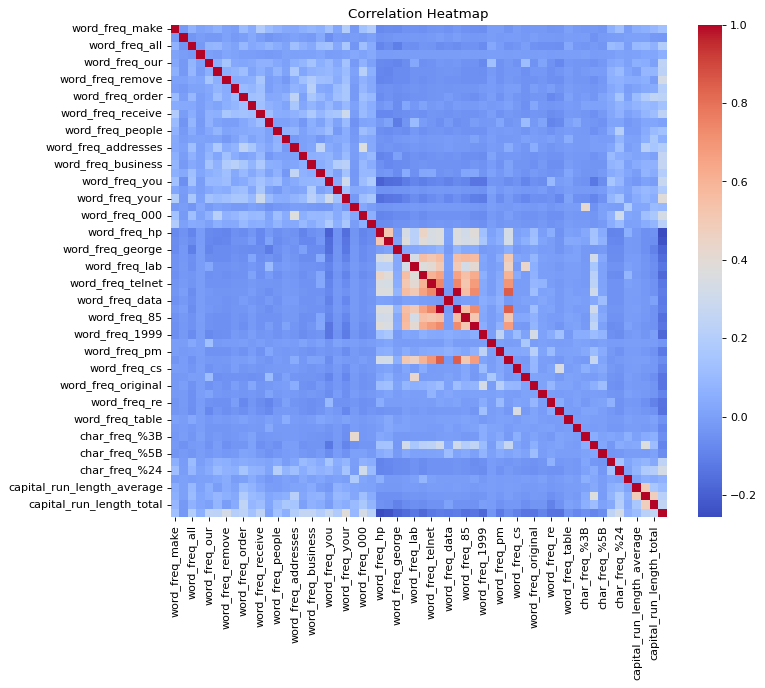

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


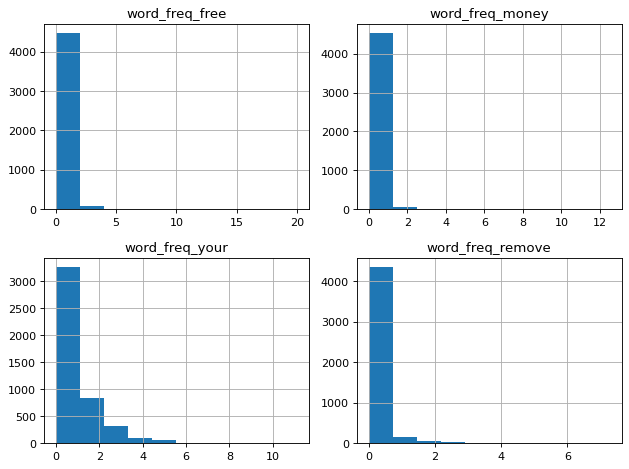

In [ ]:
important_cols = ['word_freq_free', 'word_freq_money', 'word_freq_your', 'word_freq_remove']

df[important_cols].hist(figsize=(8,6))
plt.tight_layout()
plt.show()


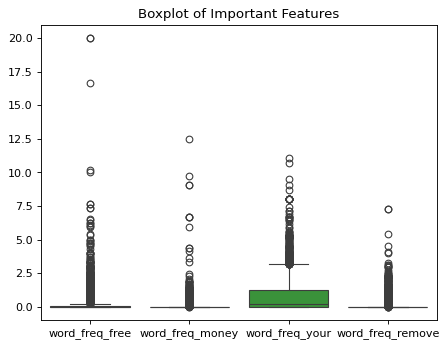

In [ ]:
sns.boxplot(data=df[important_cols])
plt.title("Boxplot of Important Features")
plt.show()


## 3. Data Preprocessing and Splitting

In [ ]:
X = df.drop(columns=['class'])
y = df['class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 3680
Test size: 921


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling done")


Feature scaling done


## 4. Train Naive Bayes Classifiers

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_prob)
    }


In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
gnb_metrics = evaluate(gnb, X_test_scaled, y_test)
gnb_metrics


{'Accuracy': 0.8327904451682954, 'Precision': 0.7145790554414785, 'Recall': 0.9586776859504132, 'F1': 0.8188235294117647, 'ROC-AUC': 0.9376116986087661}

In [ ]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(X_train, y_train)
mnb_metrics = evaluate(mnb, X_test, y_test)
mnb_metrics


{'Accuracy': 0.7763300760043431, 'Precision': 0.7198879551820728, 'Recall': 0.7079889807162535, 'F1': 0.7138888888888889, 'ROC-AUC': 0.8248121488590697}

In [ ]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train, y_train)
bnb_metrics = evaluate(bnb, X_test, y_test)
bnb_metrics


{'Accuracy': 0.8762214983713354, 'Precision': 0.8716417910447761, 'Recall': 0.8044077134986226, 'F1': 0.836676217765043, 'ROC-AUC': 0.9496455266249987}

In [ ]:
nb_comparison = pd.DataFrame({
    'Gaussian': gnb_metrics,
    'Multinomial': mnb_metrics,
    'Bernoulli': bnb_metrics
}).round(3)

nb_comparison


,Gaussian,Multinomial,Bernoulli
Accuracy,0.833,0.776,0.876
Precision,0.715,0.720,0.872
Recall,0.959,0.708,0.804
F1,0.819,0.714,0.837
ROC-AUC,0.938,0.825,0.950


## 5. KNN with Varying k

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    m = evaluate(knn, X_test_scaled, y_test)
    knn_results.append([k, m['Accuracy'], m['Precision'], m['Recall'], m['F1']])

knn_table = pd.DataFrame(knn_results, columns=['k', 'Accuracy', 'Precision', 'Recall', 'F1']).round(3)
knn_table


,k,Accuracy,Precision,Recall,F1
0,1,0.899,0.879,0.862,0.871
1,3,0.898,0.873,0.868,0.870
2,5,0.908,0.886,0.879,0.882
3,7,0.909,0.893,0.873,0.883
4,9,0.909,0.893,0.873,0.883
5,11,0.910,0.900,0.868,0.884


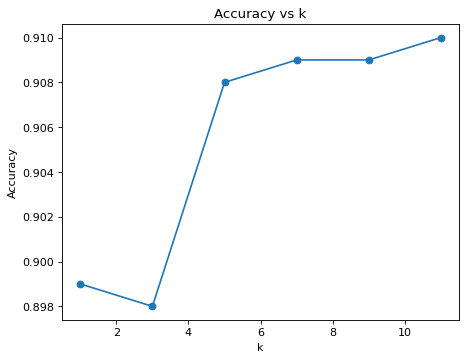

In [ ]:
plt.plot(knn_table['k'], knn_table['Accuracy'], marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.show()


## 6. Hyperparameter Tuning for KNN

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['kd_tree', 'ball_tree']
}

start = time.time()
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
grid_time = time.time() - start

print("Best Params:", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_, 3))
print("Time taken:", round(grid_time, 2), "sec")


Best Params: {'algorithm': 'kd_tree', 'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.917
Time taken: 11.43 sec


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

start = time.time()
random_search = RandomizedSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy',
                                    n_iter=8, random_state=42)
random_search.fit(X_train_scaled, y_train)
random_time = time.time() - start

print("Best Params:", random_search.best_params_)
print("Best CV Accuracy:", round(random_search.best_score_, 3))
print("Time taken:", round(random_time, 2), "sec")


Best Params: {'weights': 'distance', 'n_neighbors': 3, 'algorithm': 'kd_tree'}
Best CV Accuracy: 0.917
Time taken: 5.62 sec


In [ ]:
search_comparison = pd.DataFrame({
    'GridSearchCV': [grid_search.best_params_['n_neighbors'], grid_search.best_params_['weights'],
                      grid_search.best_params_['algorithm'], round(grid_search.best_score_, 3), round(grid_time, 2)],
    'RandomizedSearchCV': [random_search.best_params_['n_neighbors'], random_search.best_params_['weights'],
                            random_search.best_params_['algorithm'], round(random_search.best_score_, 3), round(random_time, 2)]
}, index=['Best k', 'Weights', 'Algorithm', 'CV Accuracy', 'Execution Time(s)'])

search_comparison


,GridSearchCV,RandomizedSearchCV
Best k,3,3
Weights,distance,distance
Algorithm,kd_tree,kd_tree
CV Accuracy,0.917,0.917
Execution Time(s),11.43,5.62


## 7. KDTree vs BallTree

In [ ]:
best_k = grid_search.best_params_['n_neighbors']

start = time.time()
knn_kd = KNeighborsClassifier(n_neighbors=best_k, algorithm='kd_tree')
knn_kd.fit(X_train_scaled, y_train)
kd_train_time = time.time() - start

start = time.time()
kd_pred = knn_kd.predict(X_test_scaled)
kd_pred_time = time.time() - start

kd_accuracy = accuracy_score(y_test, kd_pred)
print("KDTree done")


KDTree done


In [ ]:
start = time.time()
knn_ball = KNeighborsClassifier(n_neighbors=best_k, algorithm='ball_tree')
knn_ball.fit(X_train_scaled, y_train)
ball_train_time = time.time() - start

start = time.time()
ball_pred = knn_ball.predict(X_test_scaled)
ball_pred_time = time.time() - start

ball_accuracy = accuracy_score(y_test, ball_pred)
print("BallTree done")


BallTree done


In [ ]:
tree_comparison = pd.DataFrame({
    'KDTree': [round(kd_accuracy,3), round(kd_train_time,4), round(kd_pred_time,4)],
    'BallTree': [round(ball_accuracy,3), round(ball_train_time,4), round(ball_pred_time,4)]
}, index=['Accuracy', 'Training Time(s)', 'Prediction Time(s)'])

tree_comparison


,KDTree,BallTree
Accuracy,0.8980,0.8980
Training Time(s),0.0243,0.0193
Prediction Time(s),0.1851,0.2055


## 8. K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

best_nb_name = nb_comparison.loc['Accuracy'].idxmax()
best_nb_model = {'Gaussian': gnb, 'Multinomial': mnb, 'Bernoulli': bnb}[best_nb_name]
best_nb_data = X_train_scaled if best_nb_name == 'Gaussian' else X_train

nb_cv_scores = cross_val_score(best_nb_model, best_nb_data, y_train, cv=5)
print("Best NB:", best_nb_name)
print("CV Scores:", np.round(nb_cv_scores, 3))


Best NB: Bernoulli
CV Scores: [0.901 0.897 0.882 0.863 0.89 ]


In [ ]:
best_knn_model = KNeighborsClassifier(n_neighbors=best_k,
                                       weights=grid_search.best_params_['weights'],
                                       algorithm=grid_search.best_params_['algorithm'])

knn_cv_scores = cross_val_score(best_knn_model, X_train_scaled, y_train, cv=5)
print("CV Scores:", np.round(knn_cv_scores, 3))


CV Scores: [0.927 0.914 0.913 0.902 0.929]


In [ ]:
cv_table = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5, 'Average'],
    'Naive Bayes': list(np.round(nb_cv_scores, 3)) + [round(nb_cv_scores.mean(), 3)],
    'Best KNN': list(np.round(knn_cv_scores, 3)) + [round(knn_cv_scores.mean(), 3)]
})

cv_table


,Fold,Naive Bayes,Best KNN
0,1,0.901,0.927
1,2,0.897,0.914
2,3,0.882,0.913
3,4,0.863,0.902
4,5,0.890,0.929
5,Average,0.886,0.917


## 9. Training and Prediction Time Analysis

In [ ]:
def measure_time(model, X_tr, y_tr, X_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    start = time.time()
    model.predict(X_te)
    predict_time = time.time() - start
    return train_time, predict_time

gnb_t = measure_time(GaussianNB(), X_train_scaled, y_train, X_test_scaled)
mnb_t = measure_time(MultinomialNB(), X_train, y_train, X_test)
bnb_t = measure_time(BernoulliNB(), X_train, y_train, X_test)
knn_t = measure_time(KNeighborsClassifier(n_neighbors=best_k), X_train_scaled, y_train, X_test_scaled)

time_table = pd.DataFrame({
    'Gaussian NB': gnb_t, 'Multinomial NB': mnb_t, 'Bernoulli NB': bnb_t, 'Best KNN': knn_t
}, index=['Training(s)', 'Prediction(s)']).round(4)

time_table


,Gaussian NB,Multinomial NB,Bernoulli NB,Best KNN
Training(s),0.0031,0.0031,0.0048,0.0010
Prediction(s),0.0006,0.0012,0.0019,0.0211


## 10. Evaluation Plots

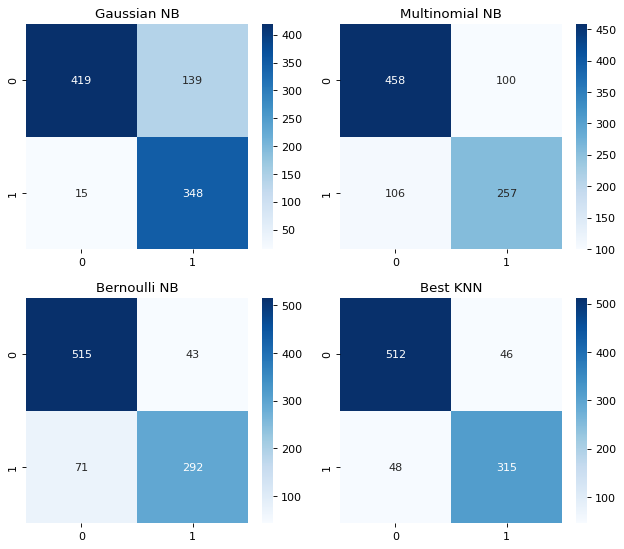

In [ ]:
from sklearn.metrics import confusion_matrix

models = {'Gaussian NB': (gnb, X_test_scaled), 'Multinomial NB': (mnb, X_test),
          'Bernoulli NB': (bnb, X_test), 'Best KNN': (knn_kd, X_test_scaled)}

fig, axes = plt.subplots(2, 2, figsize=(8,7))
for ax, (name, (model, X_te)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()


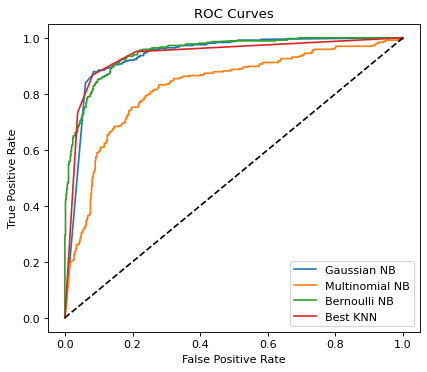

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(6,5))
for name, (model, X_te) in models.items():
    y_prob = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


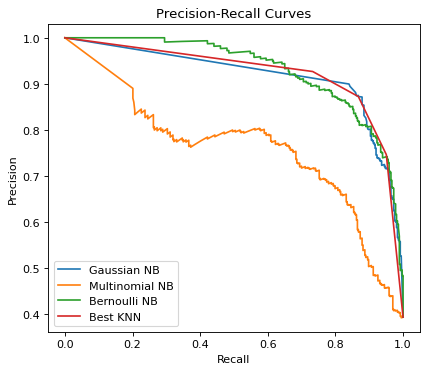

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(6,5))
for name, (model, X_te) in models.items():
    y_prob = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(rec, prec, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()


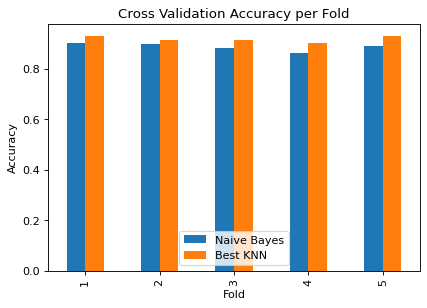

In [ ]:
cv_table.iloc[:5].plot(x='Fold', y=['Naive Bayes', 'Best KNN'], kind='bar', figsize=(6,4))
plt.ylabel("Accuracy")
plt.title("Cross Validation Accuracy per Fold")
plt.show()


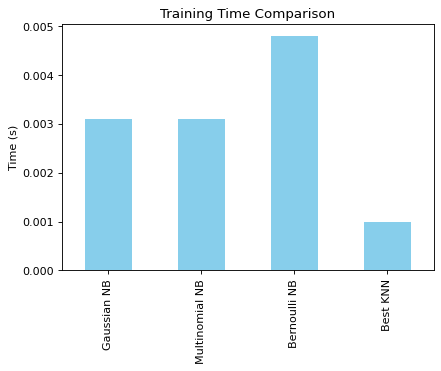

In [ ]:
time_table.loc['Training(s)'].plot(kind='bar', color='skyblue', figsize=(6,4))
plt.ylabel("Time (s)")
plt.title("Training Time Comparison")
plt.show()


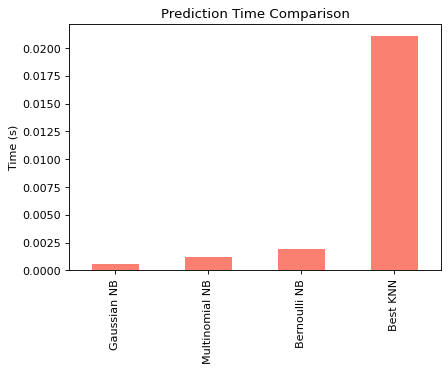

In [ ]:
time_table.loc['Prediction(s)'].plot(kind='bar', color='salmon', figsize=(6,4))
plt.ylabel("Time (s)")
plt.title("Prediction Time Comparison")
plt.show()


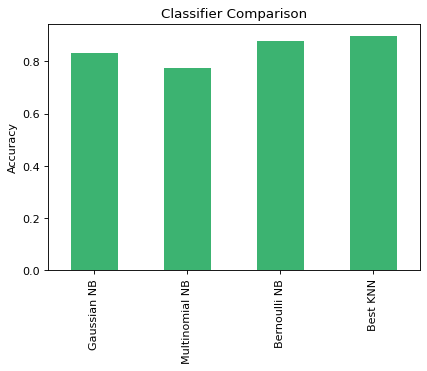

In [ ]:
final_accuracies = {
    'Gaussian NB': gnb_metrics['Accuracy'],
    'Multinomial NB': mnb_metrics['Accuracy'],
    'Bernoulli NB': bnb_metrics['Accuracy'],
    'Best KNN': kd_accuracy
}

pd.Series(final_accuracies).plot(kind='bar', color='mediumseagreen', figsize=(6,4))
plt.ylabel("Accuracy")
plt.title("Classifier Comparison")
plt.show()


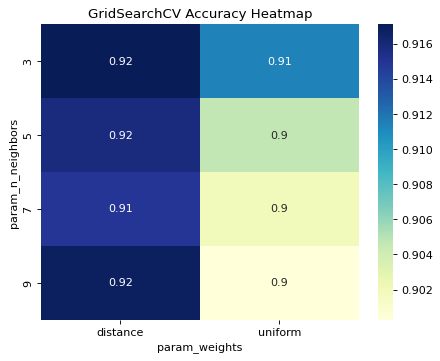

In [ ]:
grid_results = pd.DataFrame(grid_search.cv_results_)
pivot = grid_results.pivot_table(values='mean_test_score', index='param_n_neighbors', columns='param_weights')

sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title("GridSearchCV Accuracy Heatmap")
plt.show()


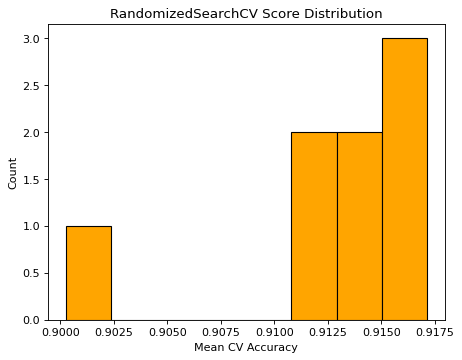

In [ ]:
random_results = pd.DataFrame(random_search.cv_results_)

plt.hist(random_results['mean_test_score'], bins=8, color='orange', edgecolor='black')
plt.xlabel("Mean CV Accuracy")
plt.ylabel("Count")
plt.title("RandomizedSearchCV Score Distribution")
plt.show()


## 11. Additional Tasks

In [ ]:
split_ratios = [0.3, 0.2, 0.1]
split_results = []

for ts in split_ratios:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=ts, random_state=42, stratify=y)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(Xtr_s, ytr)
    acc = accuracy_score(yte, knn.predict(Xte_s))
    split_results.append([f"{int((1-ts)*100)}-{int(ts*100)}", round(acc,3)])

pd.DataFrame(split_results, columns=['Train-Test Split', 'Accuracy'])


,Train-Test Split,Accuracy
0,70-30,0.897
1,80-20,0.898
2,90-10,0.879


In [ ]:
distance_results = []
for metric in ['euclidean', 'manhattan']:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    distance_results.append([metric, round(acc,3)])

pd.DataFrame(distance_results, columns=['Distance Metric', 'Accuracy'])


,Distance Metric,Accuracy
0,euclidean,0.898
1,manhattan,0.908


In [ ]:
weight_results = []
for w in ['uniform', 'distance']:
    knn = KNeighborsClassifier(n_neighbors=best_k, weights=w)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    weight_results.append([w, round(acc,3)])

pd.DataFrame(weight_results, columns=['Weight Type', 'Accuracy'])


,Weight Type,Accuracy
0,uniform,0.898
1,distance,0.907
